In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("/home/zz1994/packages/ABCMB")

In [4]:
from classy import Class
import jax.numpy as jnp
import numpy as np
from jax import jit, vmap, lax, grad, config, jacfwd
from jax.scipy.special import gamma, factorial
import scipy
from scipy.special import spherical_jn
import equinox as eqx
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import time

from ABCMB import main, cosmology, perturbations, spectrum
from ABCMB import constants as cnst
from ABCMB import ABCMBTools as tools
from ABCMB.hyrex import hyrex

In [5]:
spectrum.bessel_phi0_tab[:, 0].shape

(50000,)

In [6]:
phi0 = spectrum.bessel_phi0_tab
ls = spectrum.bessel_l_tab
x = spectrum.bessel_x_tab

In [7]:
x.max()

Array(5000., dtype=float64)

In [30]:
phi0[idx, i][0]

Array([1.08372790e-174, 1.17201713e-174, 1.26749042e-174, ...,
       1.11789480e-112, 1.19259644e-112, 1.27228120e-112], dtype=float64)

In [31]:
spherical_jn(l, x)

array([1.03397633e-174, 1.11825907e-174, 1.20940365e-174, ...,
       1.14416227e-112, 1.22065411e-112, 1.30225081e-112], shape=(2000,))

2000


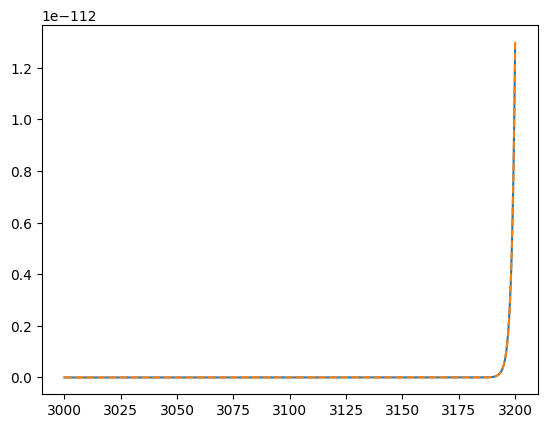

Array([ 0.04811673,  0.048073  ,  0.04802927, ..., -0.02295782,
       -0.02298576, -0.0230137 ], dtype=float64)

In [28]:
xmin = 3000
xmax = 3200
i = 130
l = ls[i]

x = spectrum.bessel_x_tab
idx = np.where((x>xmin) & (x<xmax))
x = x[idx]
print(x.size)

plt.plot(x, phi0[idx, i][0])
x = np.linspace(xmin, xmax, x.size)
plt.plot(x, spherical_jn(l, x), "--")
#plt.xlim((0, 20))
plt.show()

phi0[idx, i][0]/spherical_jn(l, x)-1.

# New Table

## $\phi_0$

In [14]:
#ls = ls[np.where(ls < 2500)]

In [45]:
newx = np.linspace(0., 5000., 50000)

In [46]:
newjl = np.zeros((newx.size, ls.size))

In [54]:
for i, l in enumerate(tqdm(ls)):
    newjl[:, i] = spherical_jn(l, newx)

  0%|          | 0/136 [00:00<?, ?it/s]

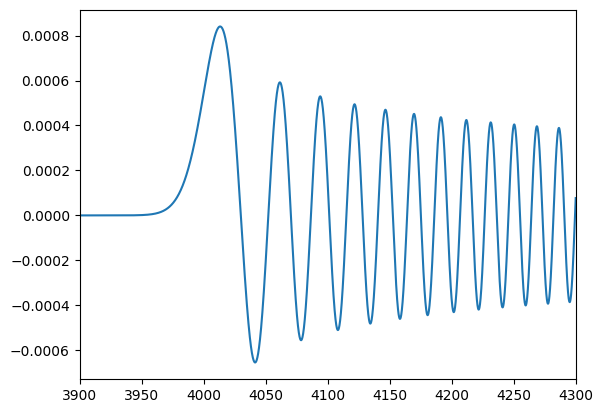

In [50]:
plt.plot(newx, newjl[:, -1])
plt.xlim((3900, 4300))
plt.show()

In [51]:
pth = "/home/zz1994/packages/ABCMB/ABCMB/new_bessel_tab"
np.savetxt(pth+"/jl.txt", newjl)
np.savetxt(pth+"/x.txt", newx)
np.savetxt(pth+"/l.txt", ls)

In [126]:
import jax
import jax.numpy as jnp
from jax import lax
import time

# A deliberately expensive function
def f(x):
    y = x
    for _ in range(200):
        y = jnp.sin(y) + jnp.cos(y)
    return y

# Generate 10_000 inputs, half above threshold
x_values = jnp.linspace(0, 4, 10_000)

# ----------------------------------------------------------
# Version 1: jnp.where (always computes f(x))
# ----------------------------------------------------------
def where_version(xs):
    def body(carry, x):
        a = carry
        a = a + jnp.where(x > 2, f(x), 0.)
        return a, None
    return lax.scan(body, 0., xs)[0]

where_jit = jax.jit(where_version)
where_jit(x_values).block_until_ready()   # warmup JIT

t0 = time.time()
where_jit(x_values).block_until_ready()
t1 = time.time()
print(f"where-version runtime: {t1 - t0:.4f} s")

# ----------------------------------------------------------
# Version 2: lax.cond (skips f(x) when x <= 2)
# ----------------------------------------------------------
def cond_version(xs):
    def body(carry, x):
        a = carry
        a = a + lax.cond(x > 2, f, lambda _: 0., x)
        return a, None
    return lax.scan(body, 0., xs)[0]

cond_jit = jax.jit(cond_version)
cond_jit(x_values).block_until_ready()    # warmup JIT

t0 = time.time()
cond_jit(x_values).block_until_ready()
t1 = time.time()
print(f"cond-version runtime:  {t1 - t0:.4f} s")


where-version runtime: 0.0459 s
cond-version runtime:  0.0245 s


## $\phi_1$

$\phi_1$ is simply the first derivative of $j_\ell$.

In [55]:
newphi1 = np.zeros((newx.size, ls.size))

In [58]:
for i, l in enumerate(tqdm(ls)):
    jlm1 = spherical_jn(l-1, newx)
    jlp1 = spherical_jn(l+1, newx)
    newphi1[:, i] = ( l*jlm1 - (l+1)*jlp1 ) / (2*l+1)

  0%|          | 0/136 [00:00<?, ?it/s]

In [60]:
pth = "/home/zz1994/packages/ABCMB/ABCMB/new_bessel_tab"
np.savetxt(pth+"/phi1.txt", newphi1)

## $\phi_2$

In [61]:
newphi2 = np.zeros((newx.size, ls.size))

In [74]:
newjl[1:10, 10]/newx[1:10]

array([1.26492959e-24, 2.58913688e-21, 2.23746724e-19, 5.29077999e-18,
       6.14901854e-17, 4.55947097e-16, 2.47903699e-15, 1.07395759e-14,
       3.91107668e-14])

In [68]:
for i, l in enumerate(tqdm(ls)):
    jl   = newjl[:, i]
    coeff = jnp.sqrt(3./8. * (l+2)*(l-1)*l*(l-1))
    

  0%|          | 0/136 [00:00<?, ?it/s]

In [64]:
pth = "/home/zz1994/packages/ABCMB/ABCMB/new_bessel_tab"
np.savetxt(pth+"/phi2.txt", newphi2)

## $\epsilon$

In [65]:
epsilon = np.zeros((newx.size, ls.size))

In [ ]:
for i, l in enumerate(tqdm(ls)):
    jl   = spherical_jn(l, newx)
    

# CLASS ells

In [43]:
index_l = 0
current_l = 2
l_linstep = 40
l_logstep = 1.12
l_max =4000
ls = np.zeros(300, dtype="int32")
ls[index_l] = current_l

increment = max(
    int(current_l * (l_logstep - 1.)),
    1
)

while current_l + increment < l_max and increment < l_linstep:
    index_l += 1
    current_l += increment
    increment = max(
        int(current_l * (l_logstep - 1.)),
        1
    )
    ls[index_l] = current_l

increment = l_linstep

while current_l + increment <= l_max:
    index_l += 1
    current_l += increment
    ls[index_l] = current_l

if current_l != l_max:
    index_l += 1
    current_l = l_max
    ls[index_l] = current_l
ls = ls[np.where(ls>0)]
print(ls)

[   2    3    4    5    6    7    8    9   10   11   12   13   14   15
   16   17   19   21   23   25   28   31   34   38   42   47   52   58
   64   71   79   88   98  109  122  136  152  170  190  212  237  265
  296  331  370  410  450  490  530  570  610  650  690  730  770  810
  850  890  930  970 1010 1050 1090 1130 1170 1210 1250 1290 1330 1370
 1410 1450 1490 1530 1570 1610 1650 1690 1730 1770 1810 1850 1890 1930
 1970 2010 2050 2090 2130 2170 2210 2250 2290 2330 2370 2410 2450 2490
 2530 2570 2610 2650 2690 2730 2770 2810 2850 2890 2930 2970 3010 3050
 3090 3130 3170 3210 3250 3290 3330 3370 3410 3450 3490 3530 3570 3610
 3650 3690 3730 3770 3810 3850 3890 3930 3970 4000]
